# Input e Install

In [ ]:
pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.5 MB/s eta 0:00:00


In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms, Atom
from ase.build import molecule, surface, bulk, add_adsorbate
from ase.io import write, read
from ase.visualize.plot import plot_atoms
from ase.constraints import FixAtoms
from ase.spacegroup import crystal
from ase.build import make_supercell

In [ ]:
pip install git+https://github.com/imagdau/aseMolec@f411b5618381ba3b807cbbb041f12f460a69d606

  Cloning https://github.com/imagdau/aseMolec (to revision f411b5618381ba3b807cbbb041f12f460a69d606) to /tmp/pip-req-build-85fgor6i
  Running command git clone --filter=blob:none --quiet https://github.com/imagdau/aseMolec /tmp/pip-req-build-85fgor6i
  Running command git rev-parse -q --verify 'sha^f411b5618381ba3b807cbbb041f12f460a69d606'
  Running command git fetch -q https://github.com/imagdau/aseMolec f411b5618381ba3b807cbbb041f12f460a69d606
  Resolved https://github.com/imagdau/aseMolec to commit f411b5618381ba3b807cbbb041f12f460a69d606
  Preparing metadata (setup.py) ... done
  Created wheel for aseMolec: filename=aseMolec-1.0.0-py3-none-any.whl size=23162 sha256=c59bedadc251a89eec38396a95b40b6469ef54d22ab752910dc52081a6daf20f
  Stored in directory: /root/.cache/pip/wheels/bf/ab/ed/45f9be5430256a5678b55aeccaeb233ab05ac03514a7805562
Successfully built aseMolec


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Comparações

Text(0.5, 0, 'Density Prob.')

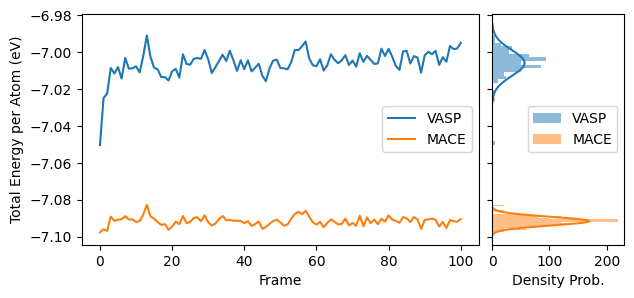

In [ ]:
from aseMolec import extAtoms as ea

traj = read('/content/drive/MyDrive/COQ878_TRABALHO/VASP_posFT.xyz', ':')
frames = np.arange(len(traj))
vasp_energies = ea.get_prop(traj, 'info', 'energy_vasp', peratom=True)
mace_energies = ea.get_prop(traj, 'info', 'energy_mace', peratom=True)

fig, axs = plt.subplots(1, 2,figsize=(7,3), sharey=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05} )

axs[0].plot(frames, vasp_energies, label='VASP')
axs[0].plot(frames, mace_energies, label='MACE')
axs[0].legend()
axs[0].set_xlabel('Frame')
axs[0].set_ylabel('Total Energy per Atom (eV)')

axs[1].hist(vasp_energies,bins=30,density=True, color='C0', alpha=0.5, label='VASP', orientation="horizontal")
axs[1].hist(mace_energies,bins=30,density=True, color='C1', alpha=0.5, label='MACE', orientation="horizontal")

Umean = np.mean(vasp_energies)
sigmaU = np.std(vasp_energies)

uarray = Umean+np.arange(-3*sigmaU,3*sigmaU,0.01*sigmaU)
axs[1].plot(np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),uarray, color='C0')

Umean = np.mean(mace_energies)
sigmaU = np.std(mace_energies)

uarray = Umean+np.arange(-3*sigmaU,3*sigmaU,0.01*sigmaU)
axs[1].plot(np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),uarray, color='C1')

axs[1].legend()
axs[1].set_xlabel('Density Prob.')

In [ ]:
RMSE = np.sqrt(np.mean((mace_energies-vasp_energies)**2))

print("RMSE entre energias do MACE e VASP: {:.3f} eV/átomo".format(RMSE))

RMSE entre energias do MACE e VASP: 0.086 eV/átomo


In [ ]:
vasp_forces = ea.get_prop(traj, 'arrays', 'forces_vasp', peratom=True)
mace_forces = ea.get_prop(traj, 'arrays', 'forces_mace', peratom=True)

RMSE_forces = np.sqrt(np.mean((mace_forces-vasp_forces)**2))

print("RMSE entre forças do MACE e VASP: {:.4f} eV/Å".format(RMSE_forces))

RMSE entre forças do MACE e VASP: 0.0014 eV/Å
